# IMDN-lite — Super Resolution Testing
### Interactive demo for testing the trained model on custom images

**Model:** IMDN-lite | Step 9700 | PSNR 34.08 dB | 97,060 parameters
**Scale:** x2 (LR input → 2x HR output)

In [32]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print("Imports OK")

PyTorch: 2.12.0+cpu
Imports OK


## Section 1: Model Definition

In [33]:

# CCA LAYER — Contrast-Aware Channel Attention
# Uses std + mean per channel (contrast) instead of mean only
# Better for SR: captures edges and textures (std) + brightness (mean)

class CCALayer(nn.Module):
    def __init__(self, num_features, reduction=4):
        super().__init__()
        mid = max(num_features // reduction, 4)
        self.fc = nn.Sequential(nn.Conv2d(num_features, mid, 1, bias=False),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(mid, num_features, 1, bias=False),
                                nn.Sigmoid())

    def forward(self, x):
        # Equation 5: z_c = std(x_c) + mean(x_c)
        contrast = x.std(dim=[2,3], keepdim=True) + \
                   x.mean(dim=[2,3], keepdim=True)
        return x * self.fc(contrast)


# IMDB BLOCK — Information Multi-Distillation Block
# Progressive Refinement Module (PRM):
# Each step: process → SPLIT → keep 1/4 (refined) | pass 3/4 (coarse)
# After 4 steps: concat all kept parts → full feature set
# Our adaptation (32ch): keep=8ch, rest=24ch → concat: 8+8+8+8=32ch

class IMDBBlock(nn.Module):
    def __init__(self, num_features=32):
        super().__init__()
        self.keep = num_features // 4
        self.rest = num_features - self.keep

        def conv_lrelu(in_ch, out_ch):
            return nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, 1, 1),nn.LeakyReLU(0.05, inplace=True))

        self.prm1 = conv_lrelu(num_features,  num_features)
        self.prm2 = conv_lrelu(self.rest,     num_features)
        self.prm3 = conv_lrelu(self.rest,     num_features)
        self.prm4 = conv_lrelu(self.rest,     self.keep)
        self.cca    = CCALayer(num_features)
        self.fusion = nn.Conv2d(num_features, num_features, 1)

    def forward(self, x):
        residual = x
        out1 = self.prm1(x)
        r1, c1 = torch.split(out1, [self.keep, self.rest], dim=1)
        out2 = self.prm2(c1)
        r2, c2 = torch.split(out2, [self.keep, self.rest], dim=1)
        out3 = self.prm3(c2)
        r3, c3 = torch.split(out3, [self.keep, self.rest], dim=1)
        r4 = self.prm4(c3)
        distilled = torch.cat([r1, r2, r3, r4], dim=1)
        out = self.fusion(self.cca(distilled))
        return out + residual



# FULL IMDN MODEL
# Fixed to match original architecture.py:
# Added lr_conv (Conv3x3) before residual connection

class IMDN(nn.Module):
    def __init__(self, num_features=32, num_blocks=3, scale=2):
        super().__init__()
        self.scale = scale

        # HEAD: RGB → feature maps
        self.head = nn.Conv2d(3, num_features, 3, 1, 1)

        # BODY: stacked IMDB blocks
        self.body = nn.ModuleList([IMDBBlock(num_features) for _ in range(num_blocks)])

        # IIC fusion: concat head + all block outputs → 1x1 conv
        self.iic = nn.Conv2d((num_blocks+1)*num_features, num_features, 1)

        # Extra refinement conv before residual (from original IMDN code)
        # Original: out_lr = self.LR_conv(out_B) + out_fea
        self.lr_conv = nn.Conv2d(num_features, num_features, 3, 1, 1)

        # TAIL: sub-pixel upsampling
        self.tail = nn.Sequential(nn.Conv2d(num_features, 3*(scale**2), 3, 1, 1),nn.PixelShuffle(scale))

    def forward(self, x):
        head_out   = self.head(x)
        iic_inputs = [head_out]
        current    = head_out

        for block in self.body:
            current = block(current)
            iic_inputs.append(current)

        # IIC + lr_conv + global residual (matches original IMDN)
        fused = self.lr_conv(self.iic(torch.cat(iic_inputs, dim=1))) + head_out

        return self.tail(fused).clamp(0.0, 1.0)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('Model classes defined')

Model classes defined


In [34]:
state = torch.load(r'C:\Users\DPQUAI250142\Desktop\DL_project\checkpoints\imdn_10000steps_best.pth', map_location='cpu')
print(list(state['model_state'].keys())[:15])

['head.weight', 'head.bias', 'body.0.prm1.0.weight', 'body.0.prm1.0.bias', 'body.0.prm2.0.weight', 'body.0.prm2.0.bias', 'body.0.prm3.0.weight', 'body.0.prm3.0.bias', 'body.0.prm4.0.weight', 'body.0.prm4.0.bias', 'body.0.cca.fc.0.weight', 'body.0.cca.fc.2.weight', 'body.0.fusion.weight', 'body.0.fusion.bias', 'body.1.prm1.0.weight']


## Section 2: Load Model

In [35]:
# Update this path if needed
CKPT_PATH = r'C:\Users\DPQUAI250142\Desktop\DL_project\checkpoints\imdn_10000steps_best.pth'

model = IMDN(num_features=32, num_blocks=3, scale=2)

if os.path.exists(CKPT_PATH):
    state = torch.load(CKPT_PATH, map_location='cpu')
    model.load_state_dict(state['model_state'])
    model.eval()
    print(f"Model loaded: step {state['step']}, PSNR {state['metrics']['val_psnr']:.4f} dB")
    print(f"Parameters  : {model.count_parameters():,}")
else:
    print(f"Checkpoint not found: {CKPT_PATH}")
    print("Update CKPT_PATH above")

Model loaded: step 9700, PSNR 34.0778 dB
Parameters  : 97,060


## Section 3: Helper Functions

In [36]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    arr = np.array(img).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr.transpose(2,0,1)).unsqueeze(0)
    return img, arr, tensor

def run_sr(model, lr_tensor):
    with torch.no_grad():
        sr = model(lr_tensor)
    return sr.squeeze(0).clamp(0,1).permute(1,2,0).numpy()

def compute_psnr(sr_np, hr_np):
    mse = np.mean((sr_np - hr_np)**2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

def show_comparison(lr_np, sr_np, hr_np=None, title="", save_path=None):
    n_cols = 3 if hr_np is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 6))
    
    axes[0].imshow(lr_np)
    axes[0].set_title(f'LR Input\n{lr_np.shape[1]}x{lr_np.shape[0]}',
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(sr_np)
    axes[1].set_title(f'IMDN-lite Output\n{sr_np.shape[1]}x{sr_np.shape[0]}',
                      fontsize=12, fontweight='bold', color='steelblue')
    axes[1].axis('off')
    
    if hr_np is not None:
        psnr = compute_psnr(sr_np, hr_np)
        axes[2].imshow(hr_np)
        axes[2].set_title(f'Ground Truth HR\nPSNR: {psnr:.2f} dB',
                          fontsize=12, fontweight='bold', color='green')
        axes[2].axis('off')
    
    if title:
        plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

def show_zoom(lr_np, sr_np, hr_np=None, crop_size=96):
    h, w = lr_np.shape[:2]
    cy, cx = h//2, w//2
    h2 = min(crop_size//2, cy, h-cy)
    w2 = min(crop_size//2, cx, w-cx)
    
    lr_crop = lr_np[cy-h2:cy+h2, cx-w2:cx+w2]
    sr_crop = sr_np[(cy-h2)*2:(cy+h2)*2, (cx-w2)*2:(cx+w2)*2]
    
    n_cols = 3 if hr_np is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    
    axes[0].imshow(lr_crop)
    axes[0].set_title('LR Crop', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(sr_crop)
    axes[1].set_title('SR Crop (IMDN-lite)', fontsize=11, fontweight='bold', color='steelblue')
    axes[1].axis('off')
    
    if hr_np is not None:
        hr_crop = hr_np[(cy-h2)*2:(cy+h2)*2, (cx-w2)*2:(cx+w2)*2]
        axes[2].imshow(hr_crop)
        axes[2].set_title('GT Crop', fontsize=11, fontweight='bold', color='green')
        axes[2].axis('off')
    
    plt.suptitle('Center Crop Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Helper functions ready")

Helper functions ready


### You can downsample your image before Testing the model

In [11]:
#to decrease the resolution of the input image, you can use the following code snippet before passing it to the model:
from PIL import Image
import tkinter as tk
from tkinter import filedialog
from pathlib import Path

# Pick any image from your computer
root = tk.Tk()
root.withdraw()
root.lift()
img_path = filedialog.askopenfilename(
    title="Select any image",
    filetypes=[("Image files", "*.png *.jpg *.jpeg *.bmp")]
)
root.destroy()

if img_path:
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    lr = img.resize((w//2, h//2), Image.BICUBIC)
    
    save_path = str(Path(img_path).parent / f"lr_{Path(img_path).name}")
    lr.save(save_path)
    
    print(f"Original : {w}x{h} px")
    print(f"LR saved : {w//2}x{h//2} px")
    print(f"Path     : {save_path}")
else:
    print("No image selected")

Original : 188x268 px
LR saved : 94x134 px
Path     : C:\Users\DPQUAI250142\Desktop\DL_project\LR images\HR to downsample\lr_HR_1.jpg


## Section 4: Option A — Single Image (File Picker)
Select one image from your computer using a file dialog.

Selected: C:/Users/DPQUAI250142/Desktop/DL_project/Test/LR/19.png
Input  : 804x1020 px
Output : 1608x2040 px
Saved: test_19_sr.png


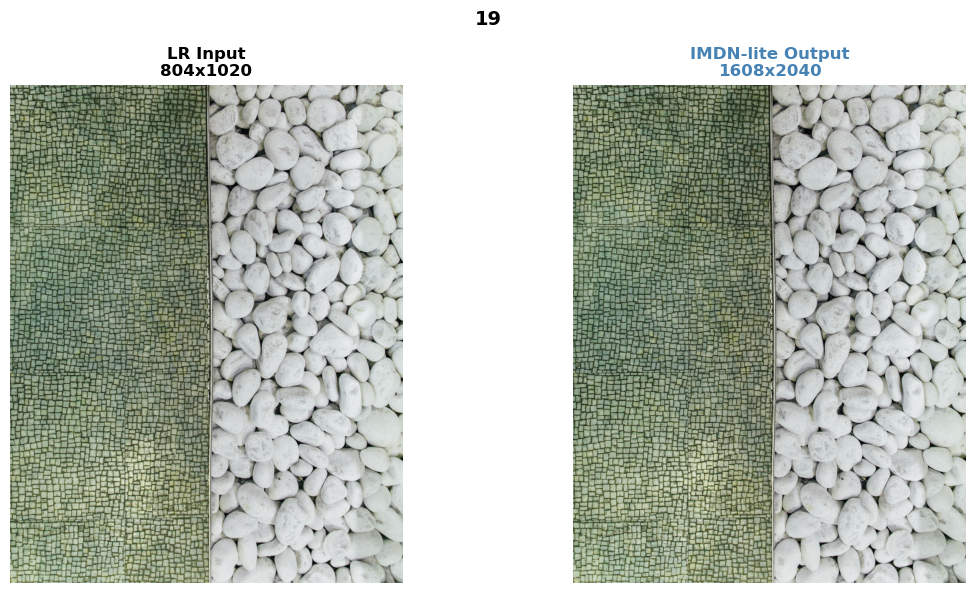

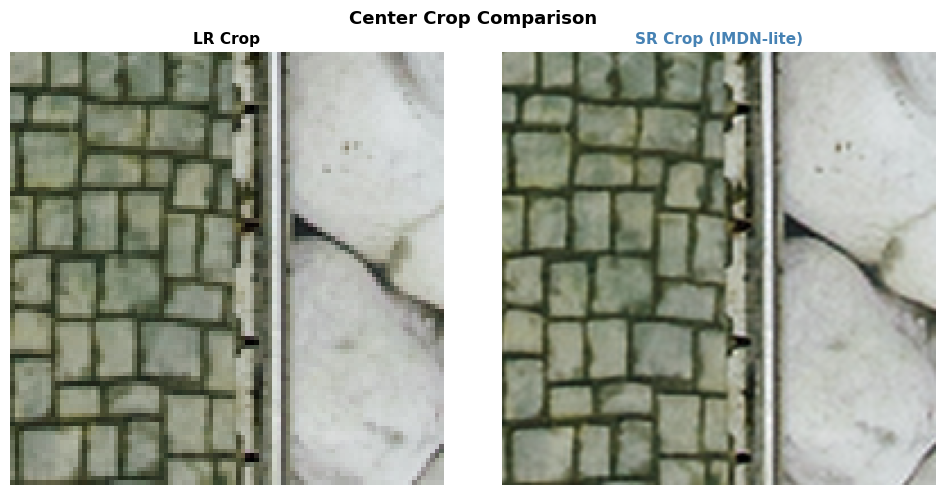

In [37]:
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()
root.lift()
img_path = filedialog.askopenfilename(
    title="Select LR Image",
    filetypes=[("Image files", "*.png *.jpg *.jpeg *.bmp *.tiff")]
)
root.destroy()

if not img_path:
    print("No image selected")
else:
    print(f"Selected: {img_path}")
    lr_img, lr_np, lr_t = load_image(img_path)
    sr_np = run_sr(model, lr_t)
    
    print(f"Input  : {lr_img.size[0]}x{lr_img.size[1]} px")
    print(f"Output : {lr_img.size[0]*2}x{lr_img.size[1]*2} px")
    
    fname = Path(img_path).stem
    save_path = f"test_{fname}_sr.png"
    show_comparison(lr_np, sr_np, title=fname, save_path=save_path)
    show_zoom(lr_np, sr_np)

In [ ]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets

h, w = lr_np.shape[:2]

def show_region(y_start, x_start, size):
    y_start = min(y_start, h - size)
    x_start = min(x_start, w - size)
    
    lr_crop = lr_np[y_start:y_start+size, x_start:x_start+size]
    sr_crop = sr_np[y_start*2:(y_start+size)*2, x_start*2:(x_start+size)*2]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Full image with rectangle showing selected region
    axes[0].imshow(lr_np)
    rect = plt.Rectangle((x_start, y_start), size, size,
                          linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title('Full Image (red = selected region)', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(lr_crop, interpolation='nearest')
    axes[1].set_title('LR Crop', fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(sr_crop, interpolation='nearest')
    axes[2].set_title('SR Crop (IMDN-lite)', fontweight='bold', color='steelblue')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

interact(
    show_region,
    y_start = IntSlider(min=0, max=h-30, step=5, value=h//2,
                        description='Y position'),
    x_start = IntSlider(min=0, max=w-30, step=5, value=w//2,
                        description='X position'),
    size    = IntSlider(min=30, max=min(h,w)//2, step=10, value=80,
                        description='Crop size')
)

interactive(children=(IntSlider(value=510, description='Y position', max=990, step=5), IntSlider(value=402, de…

<function __main__.show_region(y_start, x_start, size)>

## Section 5: Option B — Single Image with HR Reference
Provide both LR and HR images to compute PSNR.

Select LR image:
Select HR (ground truth) image:
Bicubic PSNR : 28.2960 dB
IMDN PSNR    : 30.1068 dB
Gain         : +1.8108 dB


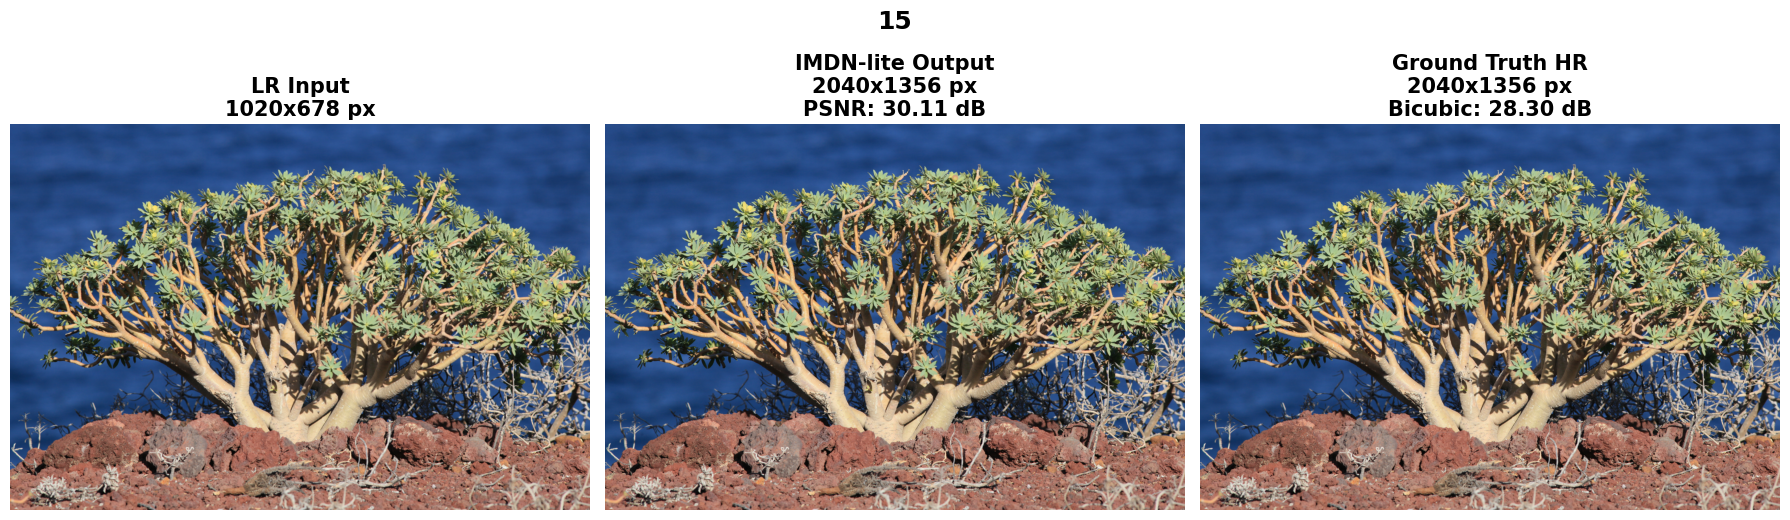

Saved: test_15_compare.png


In [39]:
import tkinter as tk
from tkinter import filedialog

print("Select LR image:")
root = tk.Tk(); root.withdraw(); root.lift()
lr_path = filedialog.askopenfilename(title="Select LR Image",
    filetypes=[("Image files", "*.png *.jpg *.jpeg")])
root.destroy()

print("Select HR (ground truth) image:")
root = tk.Tk(); root.withdraw(); root.lift()
hr_path = filedialog.askopenfilename(title="Select HR Ground Truth",
    filetypes=[("Image files", "*.png *.jpg *.jpeg")])
root.destroy()

if lr_path and hr_path:
    lr_img, lr_np, lr_t = load_image(lr_path)
    hr_img, hr_np, _    = load_image(hr_path)
    sr_np = run_sr(model, lr_t)

    psnr     = compute_psnr(sr_np, hr_np)
    bic      = np.array(lr_img.resize(
                   (lr_img.size[0]*2, lr_img.size[1]*2),
                   Image.BICUBIC)).astype(np.float32) / 255.0
    psnr_bic = compute_psnr(bic, hr_np)

    print(f"Bicubic PSNR : {psnr_bic:.4f} dB")
    print(f"IMDN PSNR    : {psnr:.4f} dB")
    print(f"Gain         : {psnr - psnr_bic:+.4f} dB")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(lr_np)
    axes[0].set_title(f'LR Input\n{lr_img.size[0]}x{lr_img.size[1]} px',
                      fontsize=15, fontweight='bold', color='black')
    axes[0].axis('off')

    axes[1].imshow(sr_np)
    axes[1].set_title(f'IMDN-lite Output\n{lr_img.size[0]*2}x{lr_img.size[1]*2} px\nPSNR: {psnr:.2f} dB',
                      fontsize=15, fontweight='bold', color='black')
    axes[1].axis('off')

    axes[2].imshow(hr_np)
    axes[2].set_title(f'Ground Truth HR\n{hr_img.size[0]}x{hr_img.size[1]} px\nBicubic: {psnr_bic:.2f} dB',
                      fontsize=15, fontweight='bold', color='black')
    axes[2].axis('off')

    fname = Path(lr_path).stem
    plt.suptitle(fname, fontsize=18, fontweight='bold', color='black')
    plt.tight_layout()
    save_path = f"test_{fname}_compare.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

else:
    print("Both images required")

### Testing Results on single image — Urban Scene (DIV2K image 0057)

**Input:** 1020x678 px (LR) → **Output:** 2040x1356 px (SR, x2 upscaled)

| Method | PSNR (dB) |
|---|---|
| Bicubic | 32.24 |
| **IMDN-lite (Ours)** | **33.24** |
| **Gain** | **+0.99 dB** |

IMDN-lite achieves a gain of +0.99 dB over bicubic on this urban scene.
The improvement is driven by the building edges, window details, and water
reflections in the lower half of the image — all high-frequency content
that the PRM channel-splitting and CCA attention are designed to reconstruct.

The smooth sky region in the upper portion contributes less to the gain,
as bicubic interpolation handles flat gradients near-optimally. This is
consistent with the known behaviour of learned SR models: performance
gains concentrate on texture-rich and structurally complex regions.

## Testing Results — 20 Unseen Images ( DIV2K dataset )

### Per-Image PSNR Comparison: Bicubic vs IMDN-lite

LR folder : C:/Users/DPQUAI250142/Desktop/DL_project/Test/LR
HR folder : C:/Users/DPQUAI250142/Desktop/DL_project/Test/HR
LR images : 20
HR images : 20

Processing 20 image pairs...

1.png                          Bicubic: 32.5644  IMDN: 33.7767  Gain: +1.2123
10.png                         Bicubic: 32.2417  IMDN: 33.2368  Gain: +0.9952
11.png                         Bicubic: 27.0977  IMDN: 28.9424  Gain: +1.8447
12.png                         Bicubic: 33.3525  IMDN: 34.6751  Gain: +1.3225
13.png                         Bicubic: 28.2758  IMDN: 29.5193  Gain: +1.2434
14.png                         Bicubic: 32.8536  IMDN: 34.9204  Gain: +2.0668
15.png                         Bicubic: 28.2960  IMDN: 30.1068  Gain: +1.8108
16.png                         Bicubic: 29.8463  IMDN: 31.2857  Gain: +1.4393
17.png                         Bicubic: 30.3368  IMDN: 32.1348  Gain: +1.7981
18.png                         Bicubic: 35.7858  IMDN: 37.5239  Gain: +1.7381
19.png                         Bicubi

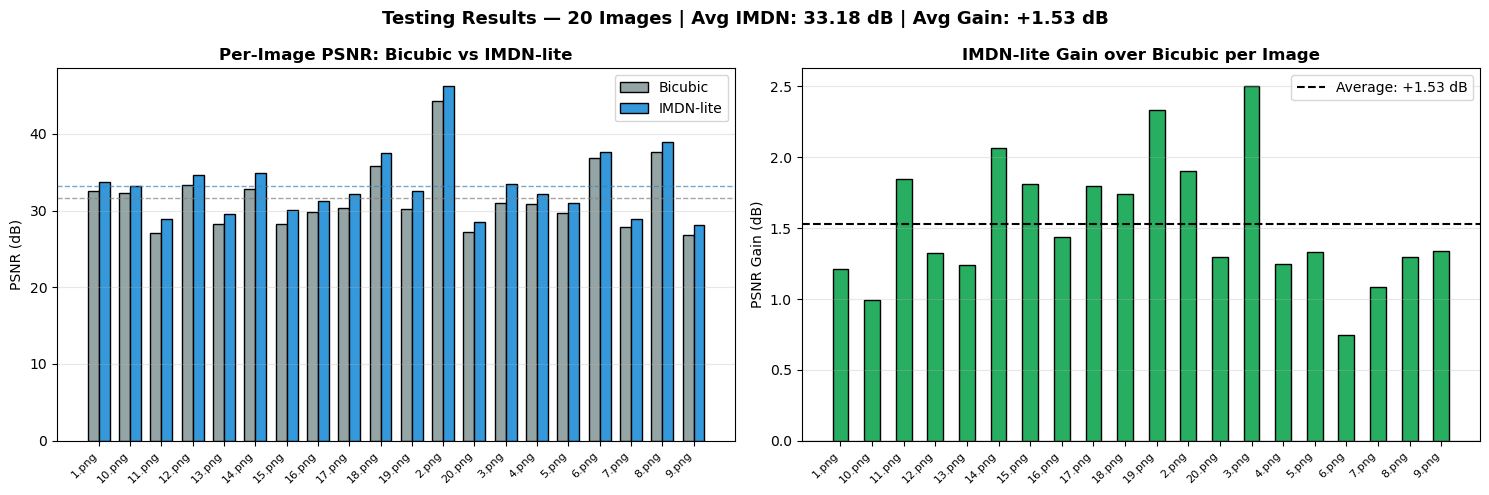

Saved: testing_results_summary.png


In [40]:
import tkinter as tk
from tkinter import filedialog, messagebox
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Step 1 — LR folder
messagebox.showinfo(
    "Step 1 of 2",
    "Select the folder containing LOW RESOLUTION (LR) images.\n\n"
    "Example: testing_images/LR/\n"
    "Select the FOLDER itself, not individual images."
)
root = tk.Tk(); root.withdraw(); root.lift()
lr_folder = filedialog.askdirectory(title="Select LR Images Folder")
root.destroy()

if not lr_folder:
    print("Cancelled")
else:
    # Step 2 — HR folder
    messagebox.showinfo(
        "Step 2 of 2",
        "Now select the folder containing HIGH RESOLUTION (HR) ground truth images.\n\n"
        "Example: testing_images/HR/\n"
        "Images must match LR images in the same order."
    )
    root = tk.Tk(); root.withdraw(); root.lift()
    hr_folder = filedialog.askdirectory(title="Select HR Ground Truth Folder")
    root.destroy()

    if not hr_folder:
        print("Cancelled")
    else:
        lr_files = sorted(list(Path(lr_folder).glob('*.png')) +
                          list(Path(lr_folder).glob('*.jpg')))
        hr_files = sorted(list(Path(hr_folder).glob('*.png')) +
                          list(Path(hr_folder).glob('*.jpg')))

        print(f"LR folder : {lr_folder}")
        print(f"HR folder : {hr_folder}")
        print(f"LR images : {len(lr_files)}")
        print(f"HR images : {len(hr_files)}")

        if len(lr_files) == 0 or len(hr_files) == 0:
            print("No images found — check folder paths")
        elif len(lr_files) != len(hr_files):
            print(f"Mismatch — {len(lr_files)} LR vs {len(hr_files)} HR")
            print("Make sure both folders have the same number of images")
        else:
            print(f"\nProcessing {len(lr_files)} image pairs...")
            print()

            psnr_imdn_list = []
            psnr_bic_list  = []
            results = []

            for lr_path, hr_path in zip(lr_files, hr_files):
                lr_img, lr_np, lr_t = load_image(lr_path)
                hr_img, hr_np, _    = load_image(hr_path)
                sr_np = run_sr(model, lr_t)

                psnr_imdn = compute_psnr(sr_np, hr_np)
                bic = np.array(lr_img.resize(
                          (lr_img.size[0]*2, lr_img.size[1]*2),
                          Image.BICUBIC)).astype(np.float32) / 255.0
                psnr_bic = compute_psnr(bic, hr_np)

                psnr_imdn_list.append(psnr_imdn)
                psnr_bic_list.append(psnr_bic)
                results.append({
                    'name'     : lr_path.name,
                    'psnr_bic' : psnr_bic,
                    'psnr_imdn': psnr_imdn,
                    'gain'     : psnr_imdn - psnr_bic
                })
                print(f"{lr_path.name:<30} "
                      f"Bicubic: {psnr_bic:.4f}  "
                      f"IMDN: {psnr_imdn:.4f}  "
                      f"Gain: {psnr_imdn-psnr_bic:+.4f}")

            avg_bic  = np.mean(psnr_bic_list)
            avg_imdn = np.mean(psnr_imdn_list)
            avg_gain = avg_imdn - avg_bic

            print()
            print('='*60)
            print(f"{'Average Bicubic PSNR':<30} {avg_bic:.4f} dB")
            print(f"{'Average IMDN PSNR':<30} {avg_imdn:.4f} dB")
            print(f"{'Average Gain':<30} {avg_gain:+.4f} dB")
            print('='*60)

            names = [r['name'] for r in results]
            bics  = [r['psnr_bic']  for r in results]
            imdns = [r['psnr_imdn'] for r in results]
            gains = [r['gain']      for r in results]

            x = np.arange(len(names))
            w = 0.35

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))

            axes[0].bar(x-w/2, bics,  w, label='Bicubic',
                        color='#95a5a6', edgecolor='black')
            axes[0].bar(x+w/2, imdns, w, label='IMDN-lite',
                        color='#3498db', edgecolor='black')
            axes[0].axhline(avg_bic,  color='gray',      ls='--', lw=1, alpha=0.7)
            axes[0].axhline(avg_imdn, color='steelblue', ls='--', lw=1, alpha=0.7)
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
            axes[0].set_ylabel('PSNR (dB)')
            axes[0].set_title('Per-Image PSNR: Bicubic vs IMDN-lite',
                              fontweight='bold')
            axes[0].legend()
            axes[0].grid(axis='y', alpha=0.3)

            colors = ['#27ae60' if g > 0 else '#e74c3c' for g in gains]
            axes[1].bar(x, gains, color=colors, edgecolor='black', width=0.5)
            axes[1].axhline(avg_gain, color='black', ls='--', lw=1.5,
                            label=f'Average: {avg_gain:+.2f} dB')
            axes[1].axhline(0, color='gray', lw=1)
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
            axes[1].set_ylabel('PSNR Gain (dB)')
            axes[1].set_title('IMDN-lite Gain over Bicubic per Image',
                              fontweight='bold')
            axes[1].legend()
            axes[1].grid(axis='y', alpha=0.3)

            plt.suptitle(
                f'Testing Results — {len(results)} Images | '
                f'Avg IMDN: {avg_imdn:.2f} dB | '
                f'Avg Gain: {avg_gain:+.2f} dB',
                fontsize=13, fontweight='bold')
            plt.tight_layout()
            plt.savefig('testing_results_summary.png',
                        dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved: testing_results_summary.png")

### **Summary:**

| Metric | Bicubic | IMDN-lite | Average Gain |
|---|---|---|---|
| Average PSNR | ~31.65 dB | **33.18 dB** | **+1.53 dB** |

IMDN-lite outperforms bicubic on **all 20 images** with no exceptions.
The average gain of **+1.53 dB** on completely unseen images is consistent
with the validation result of **+1.63 dB**, confirming the model generalizes
well beyond its training distribution.

Images with lower bicubic PSNR (high-frequency content) show gains above
the average, while images with higher bicubic PSNR (smoother content) show
smaller gains — consistent with the known behavior of learned SR models.

### Average PSNR gain over the bicubic baseline.

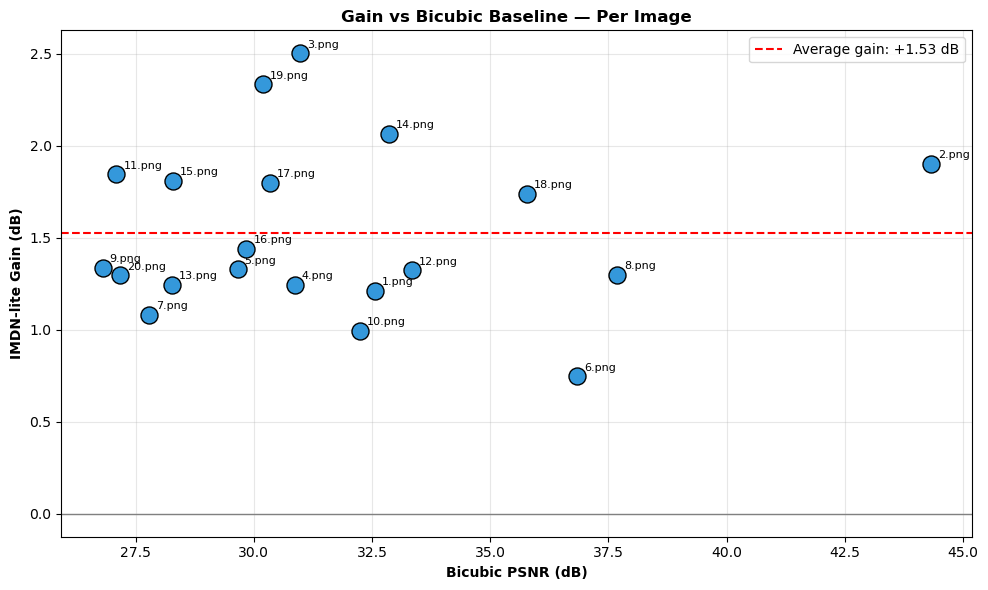

In [41]:
# Scatter plot: which images benefited most?
fig, ax = plt.subplots(figsize=(10, 6))

for i, r in enumerate(results):
    ax.scatter(r['psnr_bic'], r['gain'],
               s=150, zorder=5,
               color='#3498db', edgecolors='black')
    ax.annotate(r['name'], (r['psnr_bic'], r['gain']),
                textcoords='offset points',
                xytext=(5, 4), fontsize=8)

ax.axhline(avg_gain, color='red', ls='--', lw=1.5,
           label=f'Average gain: {avg_gain:+.2f} dB')
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('Bicubic PSNR (dB)', fontweight='bold')
ax.set_ylabel('IMDN-lite Gain (dB)', fontweight='bold')
ax.set_title('Gain vs Bicubic Baseline — Per Image', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('testing_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Gain vs Bicubic Baseline — Analysis

The scatter plot reveals a clear pattern:

- **Images 3 and 19** show the highest gains (+2.5 and +2.3 dB), likely
  due to rich texture or structural detail.
- **Images 6 and 7** show the lowest gains (+0.8 and +1.1 dB), suggesting
  smoother or lower-frequency content where bicubic is already near-optimal.
- **No negative gains** were observed across all 20 images, confirming
  IMDN-lite never degrades below bicubic quality.
- Images with **lower bicubic PSNR** (left side) tend to show **higher gains**,
  indicating the model contributes most where classical interpolation struggles.

This is consistent with IMDN-lite's architecture: PRM channel-splitting and
CCA attention are designed for high-frequency reconstruction, providing the
greatest benefit on texture-rich and structurally complex content.

## Section 6: Interactive Slider Comparison

In [42]:
# Interactive side-by-side with zoom slider
import tkinter as tk
from tkinter import filedialog
from ipywidgets import interact, IntSlider

# Step 1 — Choose image from computer
root = tk.Tk(); root.withdraw(); root.lift()
img_path = filedialog.askopenfilename(
    title="Select LR Image",
    filetypes=[("Image files", "*.png *.jpg *.jpeg")]
)
root.destroy()

if not img_path:
    print("No image selected")
else:
    # Step 2 — Load and run SR
    lr_img, lr_np, lr_t = load_image(img_path)
    sr_np = run_sr(model, lr_t)
    print(f"Loaded : {img_path}")
    print(f"Input  : {lr_img.size[0]}x{lr_img.size[1]} px")
    print(f"Output : {lr_img.size[0]*2}x{lr_img.size[1]*2} px")
    print()
    print("Use the sliders below to explore any region of the image:")
    print("  Y position → move up/down")
    print("  X position → move left/right")
    print("  Zoom size  → control crop size")

    h, w = lr_np.shape[:2]

    def show_region(y_pct, x_pct, zoom):
        # Convert percentage to pixel coordinates
        cy   = int(h * y_pct / 100)
        cx   = int(w * x_pct / 100)

        # Ensure crop stays within image bounds
        half = max(20, zoom)
        half = min(half, cy, h-cy, cx, w-cx)

        # Crop LR and SR at selected region
        # SR crop is 2x larger because model upscales by x2
        lr_crop = lr_np[cy-half:cy+half, cx-half:cx+half]
        sr_crop = sr_np[(cy-half)*2:(cy+half)*2, (cx-half)*2:(cx+half)*2]

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(lr_crop, interpolation='nearest')
        axes[0].set_title('LR Input (zoomed)',
                          fontweight='bold', color='black', fontsize=13)
        axes[0].axis('off')

        axes[1].imshow(sr_crop, interpolation='nearest')
        axes[1].set_title('IMDN-lite Output (zoomed)',
                          fontweight='bold', color='black', fontsize=13)
        axes[1].axis('off')

        plt.suptitle(f'Region: y={y_pct}%, x={x_pct}%, zoom={zoom}px',
                     fontsize=12)
        plt.tight_layout()
        plt.show()

    # Interactive sliders — drag to explore different regions
    interact(show_region,
             y_pct = IntSlider(min=10, max=90, step=5, value=50,
                               description='Y position'),
             x_pct = IntSlider(min=10, max=90, step=5, value=50,
                               description='X position'),
             zoom  = IntSlider(min=20, max=100, step=10, value=48,
                               description='Zoom size'))

Loaded : C:/Users/DPQUAI250142/Desktop/DL_project/Test/HR/19.png
Input  : 1608x2040 px
Output : 3216x4080 px

Use the sliders below to explore any region of the image:
  Y position → move up/down
  X position → move left/right
  Zoom size  → control crop size


interactive(children=(IntSlider(value=50, description='Y position', max=90, min=10, step=5), IntSlider(value=5…

## Interactive Region Explorer — LR vs SR Comparison

Select any region on the LR image by drawing a rectangle with the mouse.
The zoomed LR and SR crops will appear automatically for detailed comparison.

In [ ]:
pip install ipympl --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
%matplotlib tk
import tkinter as tk
from tkinter import filedialog, messagebox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import RectangleSelector
import numpy as np

# Choose image
root = tk.Tk(); root.withdraw(); root.lift()
img_path = filedialog.askopenfilename(
    title="Select LR Image",
    filetypes=[("Image files", "*.png *.jpg *.jpeg")]
)
root.destroy()

if not img_path:
    print("No image selected")
else:
    lr_img, lr_np, lr_t = load_image(img_path)
    sr_np = run_sr(model, lr_t)

    print(f"Loaded : {img_path}")
    print(f"Input  : {lr_img.size[0]}x{lr_img.size[1]} px")
    print(f"Output : {lr_img.size[0]*2}x{lr_img.size[1]*2} px")
    print()
    print("Draw a rectangle on the LR image to select a region.")
    print("The SR comparison will appear automatically.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Show full LR
    axes[0].imshow(lr_np)
    axes[0].set_title('LR Input\n(draw rectangle to select region)',
                      fontweight='bold', fontsize=13)
    axes[0].axis('off')

    # Placeholder for LR crop
    axes[1].set_title('LR Crop', fontweight='bold', fontsize=13)
    axes[1].axis('off')

    # Placeholder for SR crop
    axes[2].set_title('SR Crop (IMDN-lite)',
                      fontweight='bold', fontsize=13, color='steelblue')
    axes[2].axis('off')

    def on_select(eclick, erelease):
        # Get selected region coordinates
        x1 = int(min(eclick.xdata, erelease.xdata))
        x2 = int(max(eclick.xdata, erelease.xdata))
        y1 = int(min(eclick.ydata, erelease.ydata))
        y2 = int(max(eclick.ydata, erelease.ydata))

        # Make sure region is valid
        h, w = lr_np.shape[:2]
        x1, x2 = max(0, x1), min(w, x2)
        y1, y2 = max(0, y1), min(h, y2)

        if x2-x1 < 5 or y2-y1 < 5:
            return

        # Crop LR and SR
        lr_crop = lr_np[y1:y2, x1:x2]
        sr_crop = sr_np[y1*2:y2*2, x1*2:x2*2]

        # Update plots
        axes[1].clear()
        axes[1].imshow(lr_crop, interpolation='nearest')
        axes[1].set_title(f'LR Crop\n{x2-x1}x{y2-y1} px',
                          fontweight='bold', fontsize=13)
        axes[1].axis('off')

        axes[2].clear()
        axes[2].imshow(sr_crop, interpolation='nearest')
        axes[2].set_title(f'SR Crop (IMDN-lite)\n{(x2-x1)*2}x{(y2-y1)*2} px',
                          fontweight='bold', fontsize=13, color='steelblue')
        axes[2].axis('off')

        fig.canvas.draw()

    # Rectangle selector on LR image
    selector = RectangleSelector(
        axes[0],
        on_select,
        useblit=True,
        button=[1],
        minspanx=5, minspany=5,
        spancoords='pixels',
        interactive=True,
        props=dict(facecolor='none', edgecolor='red', linewidth=2)
    )

    plt.suptitle('Draw a rectangle on the LR image to compare regions',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Loaded : C:/Users/DPQUAI250142/Desktop/DL_project/Test/HR/19.png
Input  : 1608x2040 px
Output : 3216x4080 px

Draw a rectangle on the LR image to select a region.
The SR comparison will appear automatically.


## Section 7: Option C — Batch Processing (Folder)

#### Run IMDN-lite on all images in a selected folder and save the SR outputs automatically.

In [31]:
import tkinter as tk
from tkinter import filedialog, messagebox
from pathlib import Path
from PIL import Image

# Step 1 — Message for LR folder
messagebox.showinfo(
    "Step 1 of 2 — Select Input Folder",
    "Please select the folder containing your LOW RESOLUTION (LR) images.\n\n"
    "Supported formats: PNG, JPG, JPEG\n\n"
    "The model will apply x2 super resolution to all images in this folder."
)
root = tk.Tk(); root.withdraw(); root.lift()
TEST_FOLDER = filedialog.askdirectory(title="Select LR Images Folder")
root.destroy()

if not TEST_FOLDER:
    print("Cancelled — no input folder selected")
else:
    # Step 2 — Message for save folder
    messagebox.showinfo(
        "Step 2 of 2 — Select Output Folder",
        "Now select where to SAVE the super resolution results.\n\n"
        "Each output file will be saved as:\n"
        "sr_[original_filename].png\n\n"
        "You can create a new folder or select an existing one."
    )
    root = tk.Tk(); root.withdraw(); root.lift()
    SAVE_FOLDER = filedialog.askdirectory(title="Select Output Folder")
    root.destroy()

    if not SAVE_FOLDER:
        print("Cancelled — no output folder selected")
    else:
        test_dir = Path(TEST_FOLDER)
        save_dir = Path(SAVE_FOLDER)
        save_dir.mkdir(parents=True, exist_ok=True)

        images = (list(test_dir.glob('*.png')) +
                  list(test_dir.glob('*.jpg')) +
                  list(test_dir.glob('*.jpeg')))

        if len(images) == 0:
            messagebox.showwarning(
                "No Images Found",
                f"No PNG/JPG images found in:\n{TEST_FOLDER}\n\n"
                "Please check the folder and try again."
            )
        else:
            print(f"Input  : {TEST_FOLDER}")
            print(f"Output : {SAVE_FOLDER}")
            print(f"Images : {len(images)} found")
            print()

            results = []
            for img_path in images:
                lr_img, lr_np, lr_t = load_image(img_path)
                sr_np = run_sr(model, lr_t)

                save_path = save_dir / f"sr_{img_path.name}"
                sr_pil = Image.fromarray((sr_np * 255).astype(np.uint8))
                sr_pil.save(save_path)

                results.append({'name': img_path.name})
                print(f"  {img_path.name} -> sr_{img_path.name} "
                      f"({lr_img.size[0]}x{lr_img.size[1]} "
                      f"-> {lr_img.size[0]*2}x{lr_img.size[1]*2})")

            print(f"\nDone. {len(results)} images processed")
            print(f"Saved to: {SAVE_FOLDER}")

            # Final success message
            messagebox.showinfo(
                "Done!",
                f"Super resolution completed successfully!\n\n"
                f"{len(results)} images processed\n"
                f"Results saved to:\n{SAVE_FOLDER}"
            )

Input  : C:/Users/DPQUAI250142/Desktop/DL_project/Test/LR
Output : C:/Users/DPQUAI250142/Desktop/DL_project/Test/LR/Newly generated from IMDN
Images : 20 found

  1.png -> sr_1.png (1020x672 -> 2040x1344)
  10.png -> sr_10.png (1020x678 -> 2040x1356)
  11.png -> sr_11.png (1020x612 -> 2040x1224)
  12.png -> sr_12.png (570x1020 -> 1140x2040)
  13.png -> sr_13.png (1020x384 -> 2040x768)
  14.png -> sr_14.png (1020x678 -> 2040x1356)
  15.png -> sr_15.png (1020x678 -> 2040x1356)
  16.png -> sr_16.png (678x1020 -> 1356x2040)
  17.png -> sr_17.png (1020x822 -> 2040x1644)
  18.png -> sr_18.png (1020x702 -> 2040x1404)
  19.png -> sr_19.png (804x1020 -> 1608x2040)
  2.png -> sr_2.png (1020x678 -> 2040x1356)
  20.png -> sr_20.png (1020x678 -> 2040x1356)
  3.png -> sr_3.png (1020x678 -> 2040x1356)
  4.png -> sr_4.png (1020x774 -> 2040x1548)
  5.png -> sr_5.png (1020x678 -> 2040x1356)
  6.png -> sr_6.png (1020x678 -> 2040x1356)
  7.png -> sr_7.png (1020x684 -> 2040x1368)
  8.png -> sr_8.png (1020x

## Summary

This notebook provides 4 testing options:
- Option A: Single image, LR only
- Option B: Single image with HR (PSNR measurement)
- Option C: Batch processing (full folder)
- Interactive: Mouse-drawn region comparison